# импорт нужных библиотек


In [64]:
%pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [65]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import pandas as pd

# загрузка фото
разбиение на тензоры RGB
проверка размера

In [66]:
"""создал удобную функцию для изменения размера картинки"""
def do_resize(img, w=640, h=640):
    height, width, _ = img.shape
    print(f"исходный размер {width}x{height}")
    if w!=width and h!=height:
        new_img = cv2.resize(img, (w, h))
        height, width, _ = new_img.shape
        print(f"новый размер {width}x{height}")
        return new_img
    return img

In [67]:
"""уже читаем картинку через open-cv тоже для удобства"""
img = cv2.imread("img1.jpg")
img = do_resize(img, 640, 640)

исходный размер 1024x1024
новый размер 640x640


In [68]:
"""поменял этот блок
поменял с BGR на RGB
сделал разбиение на матрицы  по другому"""
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
R,G,B = cv2.split(img)

print(R, G, B)


[[44 50 56 ... 70 69 68]
 [46 46 48 ... 69 68 67]
 [48 44 42 ... 68 67 66]
 ...
 [15 15 15 ... 22 21 21]
 [15 15 15 ... 22 22 21]
 [16 16 16 ... 23 23 22]] [[34 40 45 ... 33 32 31]
 [36 36 37 ... 32 31 30]
 [38 33 31 ... 31 30 29]
 ...
 [22 22 22 ... 21 21 21]
 [22 22 22 ... 22 22 21]
 [23 23 23 ... 23 23 22]] [[35 40 44 ... 17 16 15]
 [36 35 36 ... 16 15 14]
 [37 33 30 ... 15 14 13]
 ...
 [40 40 40 ... 34 33 33]
 [40 40 40 ... 35 34 33]
 [41 41 41 ... 36 34 34]]


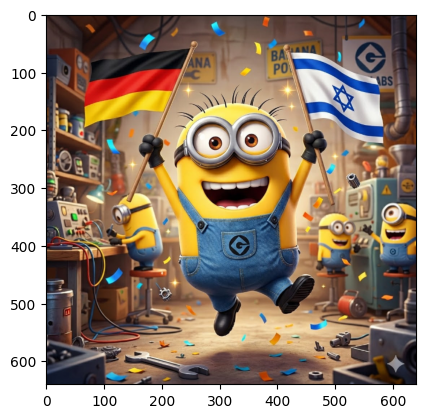

In [69]:
plt.imshow(img)

# степенной метод (пунтк №2)
формула сингулярного разложения: $A=UΣV^T$

In [70]:
def svd(A, singular_values, iter):
  U_cols, sigmas, V_cols = [], [], []
  A_curr = A.copy()

  for _ in range(singular_values):
    # random start vector
    v = np.random.randn(A_curr.shape[1])
    v = v / np.linalg.norm(v)

    # iterations
    for _ in range(iter):
      u = A_curr @ v
      sigma = np.linalg.norm(u)
      u = u / sigma
      v = A_curr.T @ u
      v = v / np.linalg.norm(v)

    U_cols.append(u)
    sigmas.append(sigma)
    V_cols.append(v)
    # вычитаем найденный вклад
    A_curr = A_curr - sigma * np.outer(u, v)

  return np.array(U_cols).T, np.array(sigmas), np.array(V_cols).T

# запуск сингулярного разложения степенным методом

In [71]:
k = 200  # сколько сингулярных чисел берём

for iter in [10, 50, 100]:
    U, Z, V = svd(R, k, iter)
    R_restored = U @ np.diag(Z) @ V.T
    error = np.linalg.norm(R - R_restored)
    print(f'iter={iter}, ошибка={error:.4f}')

iter=10, ошибка=2637.5753
iter=50, ошибка=2631.4069
iter=100, ошибка=2631.1352


ошибка ||A - U∑$V^T$|| показывает насколько воссстановленная матрица отличается от оригинала

результаты при k = 50:
  - iter=10, ошибка=9650.0330
  - iter=50, ошибка=9633.8963
  - iter=100, ошибка=9633.7525

результаты при k = 200:
  - iter=10, ошибка=2562.8590
  - iter=50, ошибка=2556.9908
  - iter=100, ошибка=2556.7037

  ### вывод по пункту 2:
  ошибка падает в зависимости от кол-ва сингулярных чисел и кол-ва итераций (но эт не сильно влияет) ⇒ улучшается точность
  
  !!! после 50 итераций ошибка почти сходится $\rightarrow$ увеличивать кол-во итераций (>100) не имеет смысла

# анализ сингулярных чисел и усеченное SVD (пунткт №3)

связь ошибки усеченного SVD со следующим сингулярным числом: $∥A−A_k​∥=\sigma_{k+1}​$

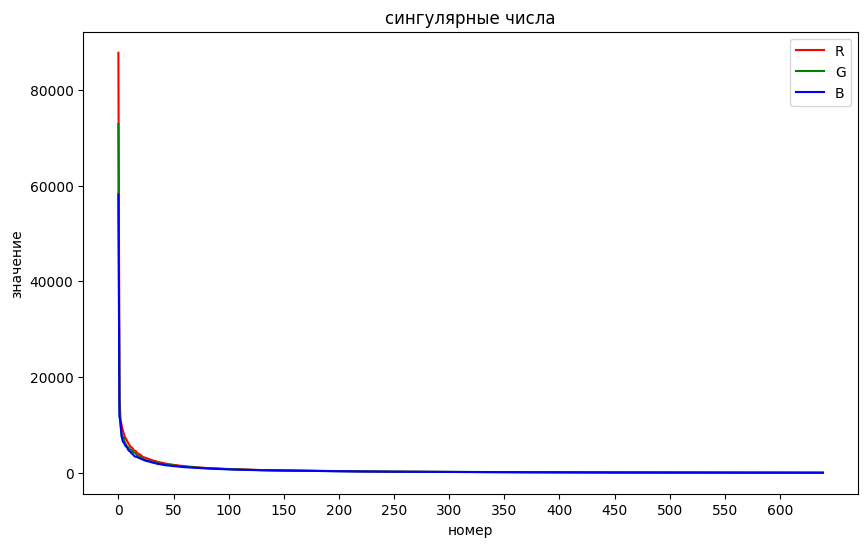

In [72]:
# get singular values
U_r, S_r, V_r = np.linalg.svd(R, full_matrices=False)
U_g, S_g, V_g = np.linalg.svd(G, full_matrices=False)
U_b, S_b, V_b = np.linalg.svd(B, full_matrices=False)

plt.figure(figsize=(10,6))
plt.plot(range(len(S_r)), S_r, color='red',label='R')
plt.plot(range(len(S_g)), S_g, color='green',label='G')
plt.plot(range(len(S_b)), S_b, color='blue',label='B')
plt.xticks(range(0, 640, 50))
plt.xlabel('номер')
plt.ylabel('значение')
plt.title('сингулярные числа')
plt.legend()
plt.show()

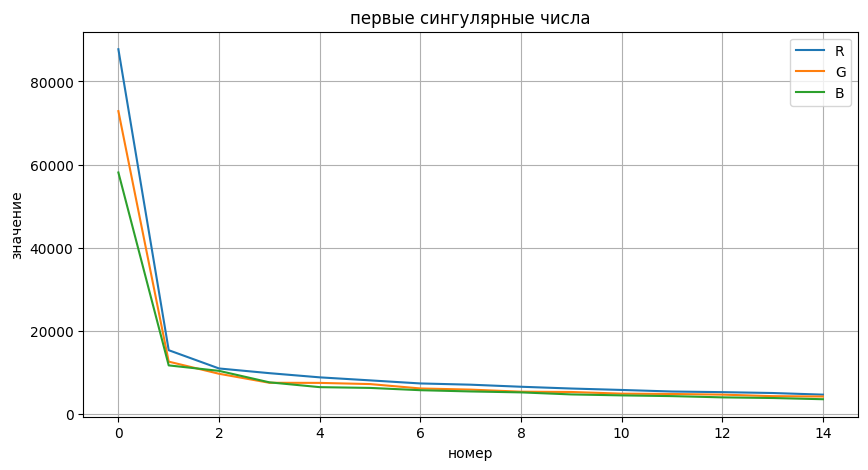

In [73]:
"""добавил график для первых сингулярных чисел
чисто для наглядности"""
n = 15

plt.figure(figsize=(10, 5))

plt.plot(S_r[:n], label="R")
plt.plot(S_g[:n], label="G")
plt.plot(S_b[:n], label="B")

plt.title("первые сингулярные числа")
plt.xlabel("номер")
plt.ylabel("значение")
plt.grid(True)
plt.legend()
plt.show()

### а) анализ графика
1) резкое падение в начале первые синг числа (<50) огромные (>80000), потом кривая обваливается ⇒ большая часть информации хранится в в первых нескольких компонентах

2) начиная с 50 номера кривая почти плоска, значения не меняются, т.е. их в клад в фотокарточку не значителен

3) все три канала ведут себя схоже, но R > G > B (в начале)

### б) предположить сколько нужно k
кривая резко убывает до 50, после практически не меняется. предположим, что k=range(0, 50) должно быть достаточно для приемлимого качества

### с) реализация усеченного разложения
$A_k =U_kΣ_kV^T_k , k ≪ min(n,m)$

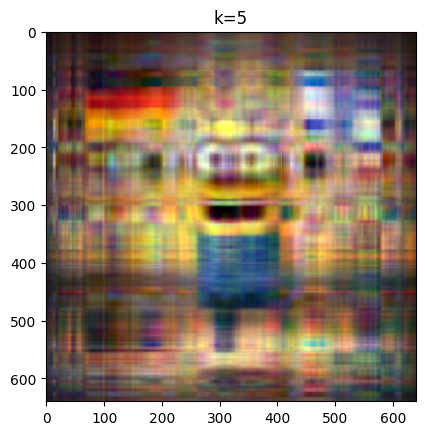

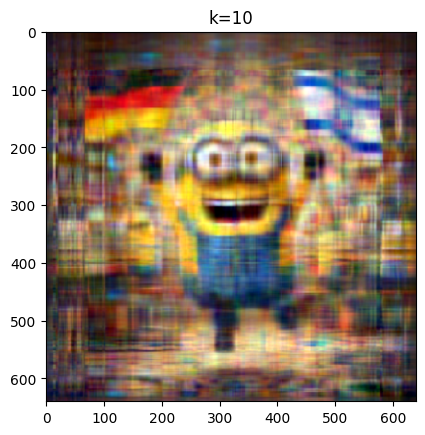

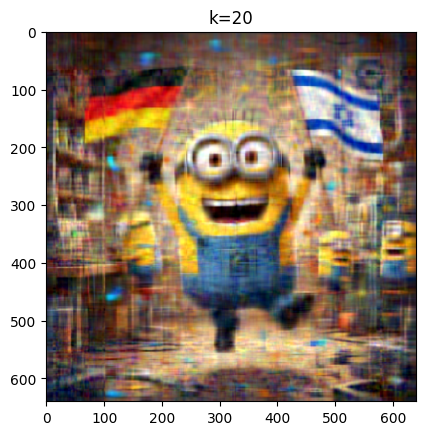

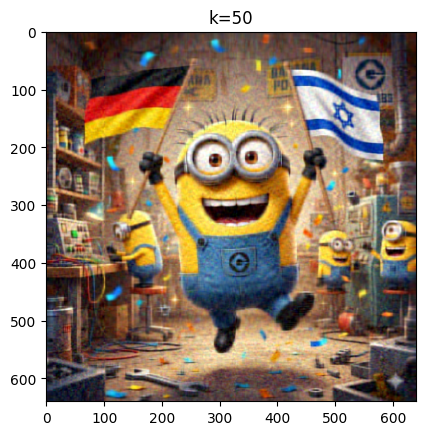

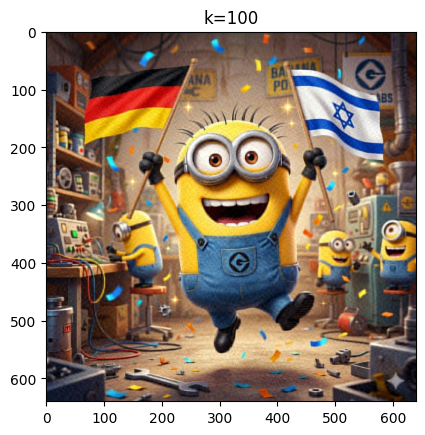

In [74]:
for k in [5, 10, 20, 50, 100]:
  R_k = U_r[:, :k]  @  np.diag(S_r[:k])  @  V_r[:k, :]
  G_k = U_g[:, :k]  @  np.diag(S_g[:k])  @  V_g[:k, :]
  B_k = U_b[:, :k]  @  np.diag(S_b[:k])  @  V_b[:k, :]

  img_restored = np.clip(np.stack([R_k, G_k, B_k], axis=2), 0, 255).astype(np.uint8)

  plt.figure()
  plt.title(f'k={k}')
  plt.imshow(img_restored)
  plt.show() # хуй

### d) вывод про картинку
картинка после восстановления стало визуально приемлимой на k=50
тк начиная с этого значения картинка визуально не отличается от оригинала, при этом объем данных значительно меньше

## Задание 4

- написал функцию ```calc_max_elem_without_diag``` которая считает максимальные числа выше диагонали и возвращает их индексы
- написал свой метод вращения якоби ```method_yakobi``` который для симметричной ...(потом более подробно напишем) 
- сравнил вариант с свд и метод якоби
- сделал сравнительную таблицу

In [ ]:
def calc_max_elem_without_diag(B, eps=1e-6): #O(n^2)
    B = np.asarray(B, dtype=float)
    max_value = 0
    p = -1
    q = -1
    n = B.shape[0]

    for i in range(n): #O(n)
        for j in range(i + 1, n): # O(n)
            if abs(B[i, j]) > abs(max_value):
                max_value = B[i, j]
                p = i
                q = j
    if abs(max_value) < eps:
        return -1, -1

    return p, q
    
def method_yakobi(A,max_iter=1000, eps = 1e-6): #O(kn^3)
    A = np.asarray(A, dtype=float)
    B = A.T @ A
    B = B.astype(float)
    n = B.shape[0]
    for _ in range(max_iter): #O(k)
        p,q = calc_max_elem_without_diag(B) # O(n^2)
        if p==-1 or q==-1: #т.е закончились максимальные эелементы вне диагонали
            break
        if np.abs(B[p][q]<eps):
            break

        r = (B[q][q] - B[p][p])/(2*B[p][q])
        if r>=0:
            t = 1/((r) + np.sqrt(1 + r**2))
        else:
            t = -1/((-1*r) + np.sqrt(1 + r**2))
        c = 1/np.sqrt(1+t**2)
        s = t*c
        J = np.eye(n)
        J[p][p] = c
        J[q][q] = c
        J[p][q] = s
        J[q][p] = -s

        B = J.T @ B @ J #O(n^3)
    evals = np.diag(B)
    singulars = np.sqrt(evals)
    singulars = np.sort(singulars)[::-1]
    return singulars

In [76]:
R,_,_ = cv2.split(img)
print(type(R))
print(R.shape)

<class 'numpy.ndarray'>
(640, 640)


In [81]:
%timeit singulars = method_yakobi(R)
%timeit  _, S_r, _ = np.linalg.svd(R, full_matrices=False)


26.9 s ± 3.9 s per loop (mean ± std. dev. of 7 runs, 1 loop each)
169 ms ± 11.2 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [82]:
singulars = method_yakobi(R)
_, S_r, _ = np.linalg.svd(R, full_matrices=False)

In [83]:
print(singulars.shape)
print(singulars[:20])

(640,)
[87751.55816886  1869.18124183  1859.44452065  1850.74718344
  1848.52065243  1845.85400278  1844.41248516  1840.79874654
  1837.48817089  1827.04740881  1825.72923448  1814.75543318
  1812.5833758   1812.1805372   1810.99438121  1807.72513039
  1804.43264843  1802.51195589  1798.41259709  1795.59124005]


In [84]:
compare = pd.DataFrame({
    "numpy_svd": S_r[:10],
    "yakobi": singulars[:10],
    "abs_diff": np.abs(S_r[:10]-singulars[:10])
})
compare

,numpy_svd,yakobi,abs_diff
0,87753.728178,87751.558169,2.170009
1,15383.194756,1869.181242,13514.013514
2,10990.361161,1859.444521,9130.916640
3,9861.067802,1850.747183,8010.320619
4,8854.378995,1848.520652,7005.858343
5,8128.271670,1845.854003,6282.417668
6,7387.116700,1844.412485,5542.704215
7,7089.050544,1840.798747,5248.251798
8,6593.649453,1837.488171,4756.161282
9,6166.689500,1827.047409,4339.642091


 - Степенной метод обычно находит только наибольшее сингулярное число
 - Метод Якоби находит все сингулярные числа, но работает тяжелее и дольше